In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import missingno as msno
from pathlib import Path
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows',100)
DATA_PATH = Path('/content/drive/MyDrive/Target Variable (1).xlsx')

df = pd.read_excel(DATA_PATH, engine='openpyxl')
if 'LOAN_APPLICATION_ID' in df.columns:
    df = df.set_index('LOAN_APPLICATION_ID', drop=True)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.head())
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.isna().sum())
df.dropna(inplace=True)
print(f'NaNs removed: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 4,838 rows × 19 columns


,DISBURSED_LIABILITY,BALANCE_AS_OF_1st Observation,BALANCE_AS_OF_-90 DPD,BALANCE_AS_OF_-60 DPD,BALANCE_AS_OF_-30 DPD,BALANCE_AS_OF_0 DPD,BALANCE_AS_OF_30 DPD,BALANCE_AS_OF_60 DPD,BALANCE_AS_OF_90 DPD,O/s on default,Default,COUNTY,WARD,FARMERS_GENDER,SALES_CHANNEL,CREDIT_SEGMENT,DEPOSIT,INTEREST_RATE,REPEAT_CUSTOMER_FLAG
LOAN_APPLICATION_ID,,,,,,,,,,,,,,,,,,,
1530738,14990,0.793195,0.718479,0.561708,0.486324,0.000000,0.000000,0.000000,0.000000,0.000000,0,Vihiga,West Bunyore,MALE,INFIELD,New_Tier 0,0.10,0.0777,False
1530769,12889,0.949569,0.709054,0.515090,0.332764,0.332764,0.138801,0.000000,0.000000,0.000000,0,Kakamega,Kisa Central,MALE,RENEWAL,Renewal_Tier 3,0.05,0.0832,True
1530797,25480,0.606005,0.821468,0.821468,0.821468,0.797920,0.768485,0.768485,0.768485,5899.000000,1,Kakamega,Namamali,MALE,INFIELD,New_Tier 2,0.10,0.0866,False
1530811,9049,0.950050,0.727926,0.672671,0.562162,0.163222,0.000000,0.000000,0.000000,0.000000,0,Kisii,Boikang'A,FEMALE,RENEWAL,Renewal_Tier 5,0.05,0.0832,True
1530938,24469,0.897830,0.897830,0.897830,0.897830,0.856962,0.856962,0.856962,0.730717,6589.084277,1,Kakamega,Chemuche,MALE,RENEWAL,Renewal_Tier 5,0.10,0.0832,True


Duplicates removed: 4,838 rows × 19 columns


,0
DISBURSED_LIABILITY,0
BALANCE_AS_OF_1st Observation,0
BALANCE_AS_OF_-90 DPD,0
BALANCE_AS_OF_-60 DPD,0
BALANCE_AS_OF_-30 DPD,0
BALANCE_AS_OF_0 DPD,0
BALANCE_AS_OF_30 DPD,0
BALANCE_AS_OF_60 DPD,0
BALANCE_AS_OF_90 DPD,0
O/s on default,0


NaNs removed: 4,837 rows × 19 columns


In [7]:
print(df.columns)
print('\n\n')
dpd_cols = [c for c in df.columns if 'BALANCE_AS_OF' in c]
print(dpd_cols)
df['DPD_SLOPE'] = df[dpd_cols].apply(lambda r: np.polyfit(range(len(dpd_cols)), r.values, 1)[0], axis=1)
df.drop(dpd_cols,axis=1,inplace=True)
df.drop("WARD",axis=1,inplace=True)
print(df.columns)
print('\n\n')

Index(['DISBURSED_LIABILITY', 'BALANCE_AS_OF_1st Observation',
       'BALANCE_AS_OF_-90 DPD', 'BALANCE_AS_OF_-60 DPD',
       'BALANCE_AS_OF_-30 DPD', 'BALANCE_AS_OF_0 DPD', 'BALANCE_AS_OF_30 DPD',
       'BALANCE_AS_OF_60 DPD', 'BALANCE_AS_OF_90 DPD', 'O/s on default',
       'Default', 'COUNTY', 'WARD', 'FARMERS_GENDER', 'SALES_CHANNEL',
       'CREDIT_SEGMENT', 'DEPOSIT', 'INTEREST_RATE', 'REPEAT_CUSTOMER_FLAG'],
      dtype='object')



['BALANCE_AS_OF_1st Observation', 'BALANCE_AS_OF_-90 DPD', 'BALANCE_AS_OF_-60 DPD', 'BALANCE_AS_OF_-30 DPD', 'BALANCE_AS_OF_0 DPD', 'BALANCE_AS_OF_30 DPD', 'BALANCE_AS_OF_60 DPD', 'BALANCE_AS_OF_90 DPD']
Index(['DISBURSED_LIABILITY', 'O/s on default', 'Default', 'COUNTY',
       'FARMERS_GENDER', 'SALES_CHANNEL', 'CREDIT_SEGMENT', 'DEPOSIT',
       'INTEREST_RATE', 'REPEAT_CUSTOMER_FLAG', 'DPD_SLOPE'],
      dtype='object')





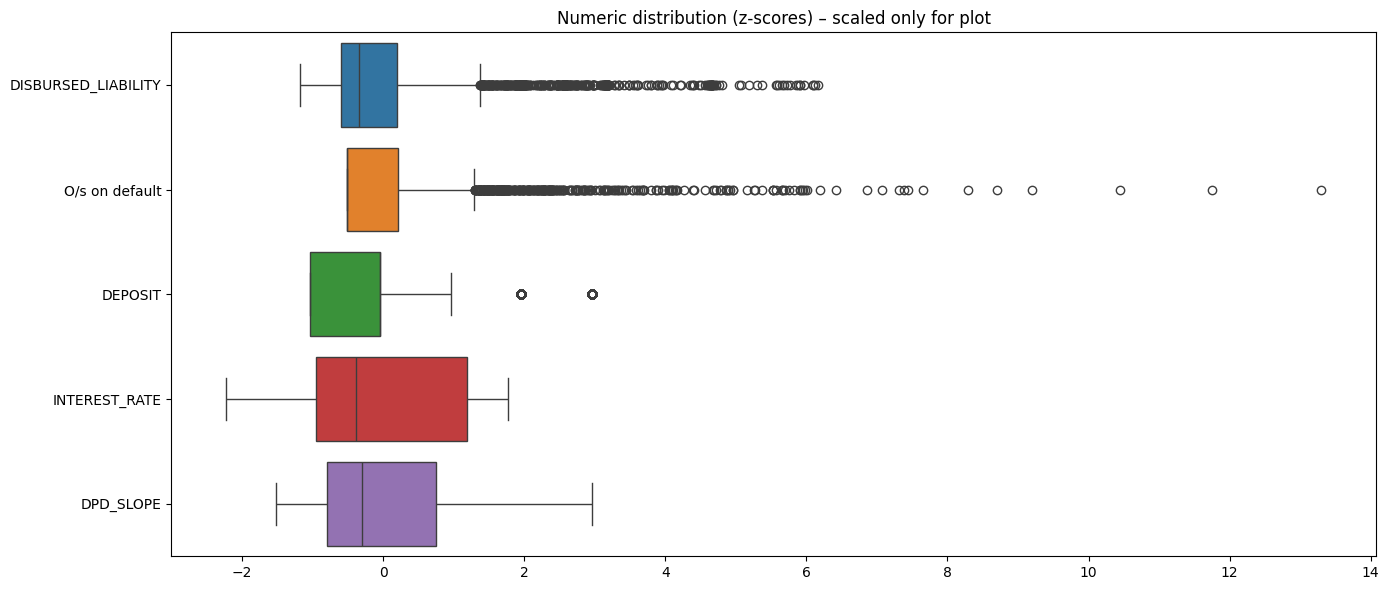

In [8]:
df1=df.drop("Default",axis=1)
num_cols = df1.select_dtypes(include=np.number).columns

scaled = pd.DataFrame(StandardScaler().fit_transform(df[num_cols]), index=df.index, columns=num_cols)
plt.figure(figsize=(14,6))
sns.boxplot(data=scaled, orient='h', showfliers=True)
plt.title('Numeric distribution (z‑scores) – scaled only for plot')
plt.tight_layout()
plt.show()


In [9]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df.reset_index(), title='Basic EDA Report', explorative=True, minimal=True)
out = Path('/content/Apollo_Files/01_basic_eda_report_final.html')
out.parent.mkdir(exist_ok=True, parents=True)
profile.to_file(out)
print('ydata_profiling HTML saved →', out)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 69.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

ydata_profiling HTML saved → /content/Apollo_Files/01_basic_eda_report_final.html


In [10]:
num = df.select_dtypes(include=np.number)
# 2️⃣  Compute IQR whisker bounds column-wise
q1 = num.quantile(0.25)
q3 = num.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# 3️⃣  Boolean mask: row is True if any numeric cell is < lower OR > upper
outlier_mask = ((num < lower) | (num > upper)).any(axis=1)
# 4️⃣  Split the DataFrame
df_outliers = df[outlier_mask]
df_clean    = df[~outlier_mask]

print(f"Outlier rows : {df_outliers.shape[0]:,}")
display(df_outliers["Default"].value_counts())
display(df_clean["Default"].value_counts())
display(df["Default"].value_counts())
display(df_clean.shape)
df=df_clean

Outlier rows : 1,153


,count
Default,
1,748
0,405


,count
Default,
0,2380
1,1304


,count
Default,
0,2785
1,2052


(3684, 11)

In [11]:
display(df['FARMERS_GENDER'].value_counts())
df['FARMERS_GENDER']=df['FARMERS_GENDER'].apply(lambda x: "FEMALE" if x=="Female" else x )
display(df['FARMERS_GENDER'].value_counts())

,count
FARMERS_GENDER,
FEMALE,2008
MALE,1675
Female,1


,count
FARMERS_GENDER,
FEMALE,2009
MALE,1675


In [12]:
display(df['REPEAT_CUSTOMER_FLAG'].value_counts())
df['REPEAT_CUSTOMER_FLAG']=df['REPEAT_CUSTOMER_FLAG'].map({True:'Yes',False:'No'})
display(df['REPEAT_CUSTOMER_FLAG'].value_counts())

,count
REPEAT_CUSTOMER_FLAG,
False,2140
True,1544


,count
REPEAT_CUSTOMER_FLAG,
No,2140
Yes,1544


Index(['COUNTY', 'FARMERS_GENDER', 'SALES_CHANNEL', 'CREDIT_SEGMENT',
       'REPEAT_CUSTOMER_FLAG'],
      dtype='object')



 COUNTY


,COUNTY,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
7,Kisumu,44,86,0.511628,0.033742,0.017647,-0.648184,0.010433,0.086434
2,Busia,99,215,0.460465,0.075920,0.048739,-0.443194,0.012046,0.086434
11,Nyamira,9,20,0.450000,0.006902,0.004622,-0.400993,0.000914,0.086434
13,Siaya,79,179,0.441341,0.060583,0.042017,-0.365942,0.006794,0.086434
10,Narok,49,117,0.418803,0.037577,0.028571,-0.273977,0.002467,0.086434
4,Kakamega,215,529,0.406427,0.164877,0.131933,-0.222909,0.007344,0.086434
6,Kisii,19,48,0.395833,0.014571,0.012185,-0.178807,0.000427,0.086434
16,Vihiga,52,139,0.374101,0.039877,0.036555,-0.087000,0.000289,0.086434
5,Kericho,61,166,0.367470,0.046779,0.044118,-0.058578,0.000156,0.086434
1,Bungoma,262,725,0.361379,0.200920,0.194538,-0.032281,0.000206,0.086434


/tmp/ipython-input-2631357710.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


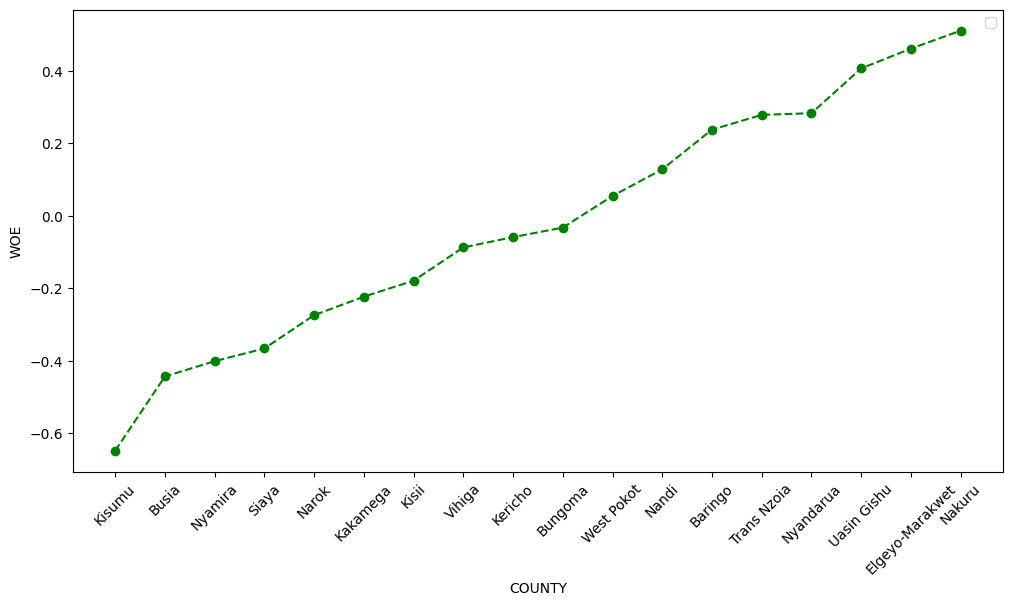



 FARMERS_GENDER


/tmp/ipython-input-2631357710.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  IV_table = pd.concat([IV_table,pd.DataFrame([{'Feature':i,'Information_Value':df_drate['IV_step'].sum()}])],ignore_index=True)


,FARMERS_GENDER,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
1,MALE,610,1675,0.364179,0.467791,0.447479,-0.044393,0.000902,0.001663
0,FEMALE,694,2009,0.345445,0.532209,0.552521,0.037456,0.000761,0.001663


/tmp/ipython-input-2631357710.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


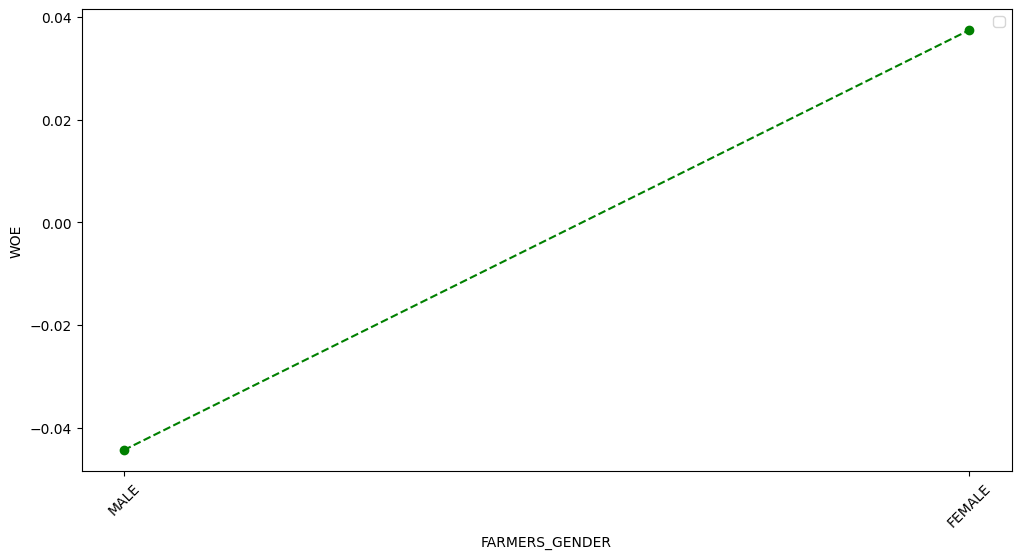



 SALES_CHANNEL


,SALES_CHANNEL,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,INFIELD,707,1568,0.450893,0.542178,0.361765,-0.404600,0.072995,0.26577
1,REFERRALS,276,626,0.440895,0.211656,0.147059,-0.364132,0.023522,0.26577
2,RENEWAL,321,1490,0.215436,0.246166,0.491176,0.690799,0.169253,0.26577


/tmp/ipython-input-2631357710.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


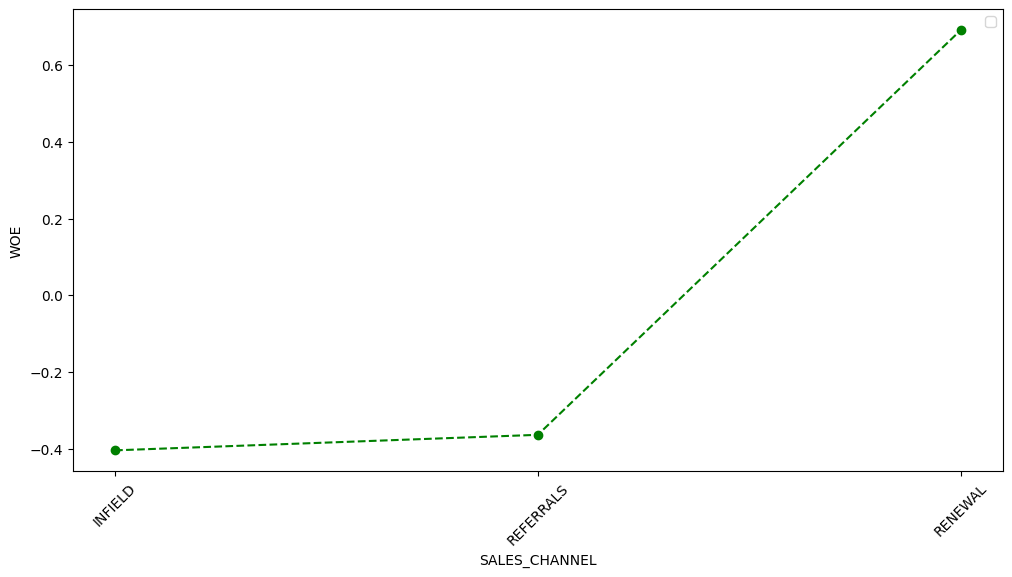



 CREDIT_SEGMENT


,CREDIT_SEGMENT,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
4,New_Tier 4,99,147,0.673469,0.075920,0.020168,-1.325583,0.073904,0.548106
3,New_Tier 3,346,598,0.578595,0.265337,0.105882,-0.918674,0.146487,0.548106
2,New_Tier 2,338,775,0.436129,0.259202,0.183613,-0.344777,0.026061,0.548106
13,Renewal_Tier 8,31,74,0.418919,0.023773,0.018067,-0.274451,0.001566,0.548106
12,Renewal_Tier 7,130,381,0.341207,0.099693,0.105462,0.056254,0.000325,0.548106
1,New_Tier 1,176,553,0.318264,0.134969,0.158403,0.160097,0.003752,0.548106
8,Renewal_Tier 3,18,88,0.204545,0.013804,0.029412,0.756459,0.011807,0.548106
5,Renewal_Others,25,129,0.193798,0.019172,0.043697,0.823851,0.020206,0.548106
11,Renewal_Tier 6,13,74,0.175676,0.009969,0.025630,0.944260,0.014788,0.548106
10,Renewal_Tier 5,34,197,0.172589,0.026074,0.068487,0.965726,0.040960,0.548106


/tmp/ipython-input-2631357710.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


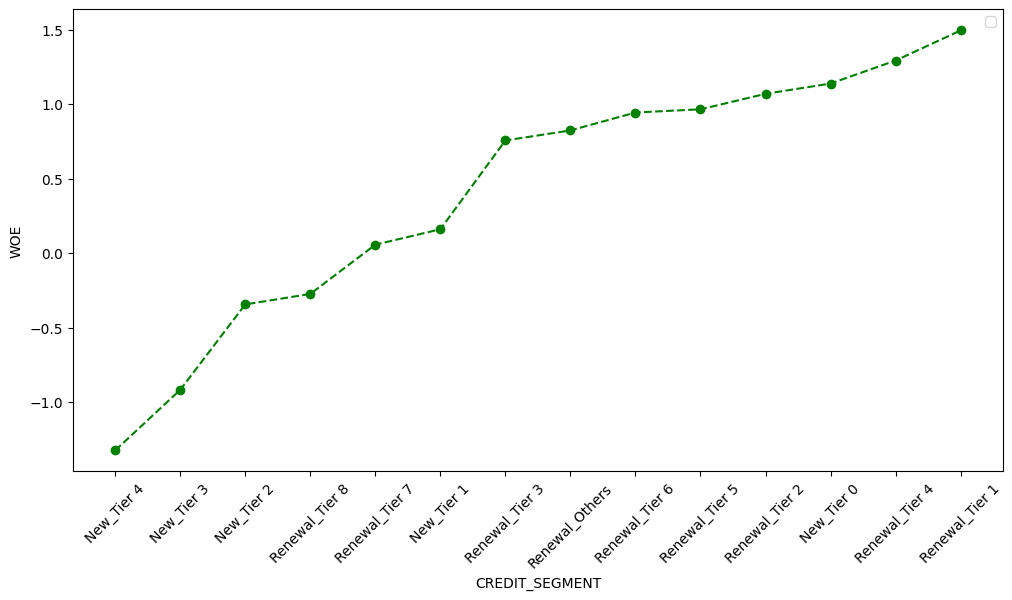



 REPEAT_CUSTOMER_FLAG


,REPEAT_CUSTOMER_FLAG,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,No,969,2140,0.452804,0.743098,0.492017,-0.412315,0.103525,0.2747
1,Yes,335,1544,0.216969,0.256902,0.507983,0.681754,0.171176,0.2747


/tmp/ipython-input-2631357710.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


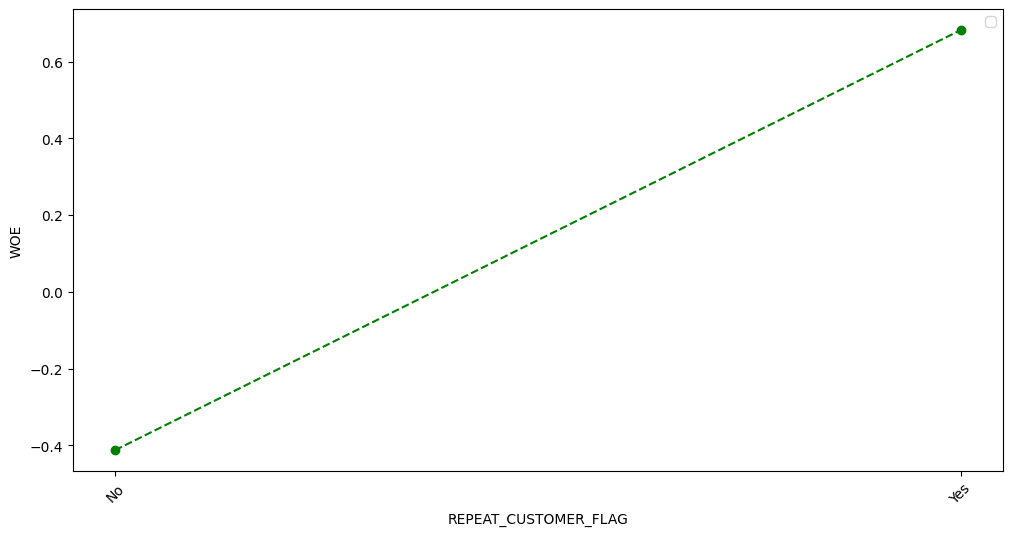

,Feature,Information_Value
3,CREDIT_SEGMENT,0.548106
4,REPEAT_CUSTOMER_FLAG,0.274700
2,SALES_CHANNEL,0.265770
0,COUNTY,0.086434
1,FARMERS_GENDER,0.001663


In [13]:
cat_cols = df.select_dtypes(include='object').columns
display(cat_cols)

IV_table=pd.DataFrame(columns=['Feature','Information_Value'])
for i in cat_cols:
  print("\n\n",i)
  df_drate=df.groupby(i)['Default'].agg(['sum','count']).reset_index()
  df_drate['def_rate']=df_drate['sum']/df_drate['count']
  df_drate['%bad']=df_drate['sum']/df_drate['sum'].sum()
  df_drate['%good']=(df_drate['count']-df_drate['sum'])/(df_drate['count'].sum()-df_drate['sum'].sum())
  df_drate['WOE']=np.log((df_drate['%good']+0.00000000000000000001)/(df_drate['%bad']+0.00000000000000000001))
  df_drate=df_drate.sort_values(by='WOE',ascending=True)
  df_drate['IV_step']=((df_drate['%good']-df_drate['%bad'])*df_drate['WOE'])
  df_drate['IV']=df_drate['IV_step'].sum()
  display(df_drate.sort_values(by='WOE',ascending=True))
  plt.figure(figsize=(12, 6))
  plt.plot(df_drate[i],df_drate['WOE'],'go--')
  plt.xlabel(i)
  plt.ylabel('WOE')
  plt.legend()
  plt.xticks(rotation=45)
  plt.show()
  IV_table = pd.concat([IV_table,pd.DataFrame([{'Feature':i,'Information_Value':df_drate['IV_step'].sum()}])],ignore_index=True)
IV_table=IV_table.sort_values(by='Information_Value',ascending=False)
display(IV_table)
# Information Value range:
# <0.02 - Unpridictible
# 0.02 to 0.1 - Weak
# 0.1 to 0.3 - Medium
# 0.3 to 0.5 - Strong
# >0.5 - Suspicious

In [14]:
df['COUNTY']=df['COUNTY'].map({
    'Narok':'Narok+West Pokot',
    'West Pokot':'Narok+West Pokot',
    'Siaya':'Siaya+Busia',
    'Busia':'Siaya+Busia',
    'Kakamega':'Kakamega+Nyamira',
    'Nyamira':'Kakamega+Nyamira',
    'Bungoma':'Bungoma+Vihiga+Nandi+Kericho+Kisii',
    'Vihiga':'Bungoma+Vihiga+Nandi+Kericho+Kisii',
    'Nandi':'Bungoma+Vihiga+Nandi+Kericho+Kisii',
    'Kericho':'Bungoma+Vihiga+Nandi+Kericho+Kisii',
    'Kisii':'Bungoma+Vihiga+Nandi+Kericho+Kisii',
    'Nakuru':'Nakuru+Uasin Gishu+Trans Nzoia',
    'Uasin Gishu':'Nakuru+Uasin Gishu+Trans Nzoia',
    'Trans Nzoia':'Nakuru+Uasin Gishu+Trans Nzoia',
    'Elgeyo-Marakwet':'Elgeyo-Marakwet+Nyandarua+Baringo',
    'Nyandarua':'Elgeyo-Marakwet+Nyandarua+Baringo',
    'Baringo':'Elgeyo-Marakwet+Nyandarua+Baringo',
    'Kisumu':'Kisumu'
})

df['CREDIT_SEGMENT']=df['CREDIT_SEGMENT'].map({
    'New_Tier 0':'New_Tier 0 + New_Tier 1',
    'New_Tier 1':'New_Tier 0 + New_Tier 1',
    'New_Tier 2':'New_Tier 2',
    'New_Tier 3':'New_Tier 3 + New_Tier 4 + New_Tier 5 + New_Tier 6',
    'New_Tier 4':'New_Tier 3 + New_Tier 4 + New_Tier 5 + New_Tier 6',
    'New_Tier 5':'New_Tier 3 + New_Tier 4 + New_Tier 5 + New_Tier 6',
    'New_Tier 6':'New_Tier 3 + New_Tier 4 + New_Tier 5 + New_Tier 6',
    'Renewal_Tier 1':'Renewal_Tier 1 + Renewal_Tier 2 + Renewal_Tier 6',
    'Renewal_Tier 2':'Renewal_Tier 1 + Renewal_Tier 2 + Renewal_Tier 6',
    'Renewal_Tier 3':'Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier 5 + Renewal_Others',
    'Renewal_Tier 4':'Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier 5 + Renewal_Others',
    'Renewal_Tier 5':'Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier 5 + Renewal_Others',
    'Renewal_Tier 6':'Renewal_Tier 1 + Renewal_Tier 2 + Renewal_Tier 6',
    'Renewal_Tier 7':'Renewal_Tier 7 + Renewal_Tier 8',
    'Renewal_Tier 8':'Renewal_Tier 7 + Renewal_Tier 8',
    'Renewal_Others':'Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier 5 + Renewal_Others'

})





 COUNTY


,COUNTY,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
3,Kisumu,44,86,0.511628,0.033742,0.017647,-0.648184,0.010433,0.080769
6,Siaya+Busia,178,394,0.451777,0.136503,0.090756,-0.408169,0.018672,0.080769
2,Kakamega+Nyamira,224,549,0.408015,0.171779,0.136555,-0.229485,0.008083,0.080769
5,Narok+West Pokot,77,199,0.386935,0.059049,0.051261,-0.141448,0.001102,0.080769
0,Bungoma+Vihiga+Nandi+Kericho+Kisii,447,1241,0.360193,0.342791,0.333613,-0.027139,0.000249,0.080769
1,Elgeyo-Marakwet+Nyandarua+Baringo,107,378,0.283069,0.082055,0.113866,0.327626,0.010422,0.080769
4,Nakuru+Uasin Gishu+Trans Nzoia,227,837,0.271207,0.174080,0.256303,0.386845,0.031807,0.080769


/tmp/ipython-input-2511047857.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


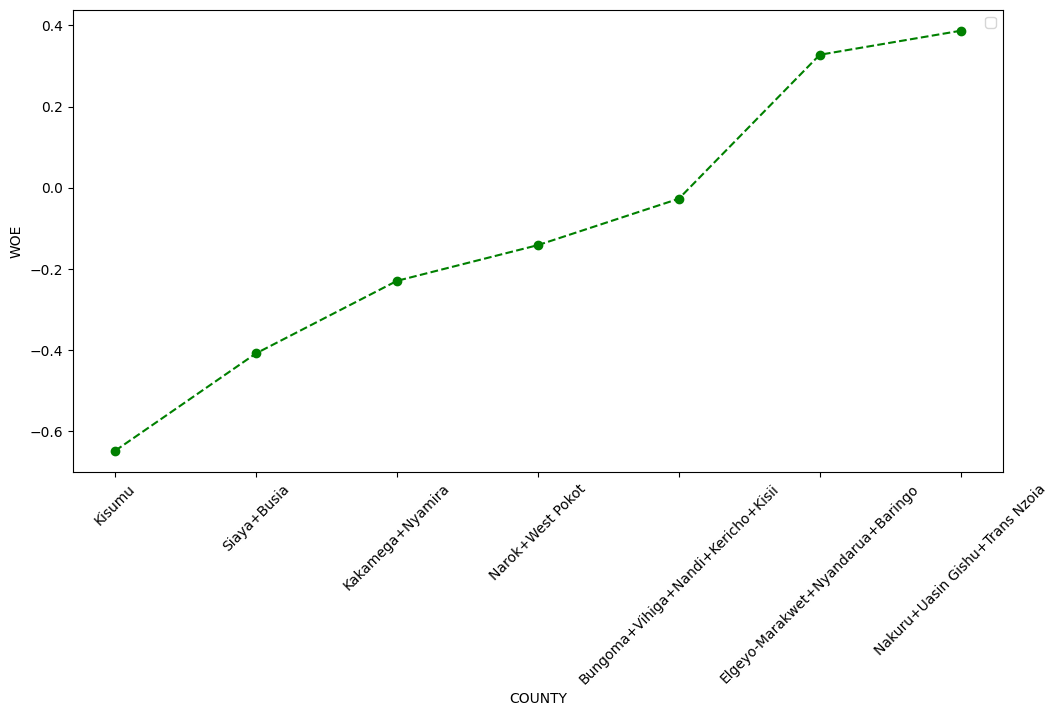



 FARMERS_GENDER


/tmp/ipython-input-2511047857.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  IV_table = pd.concat([IV_table,pd.DataFrame([{'Feature':i,'Information_Value':df_drate['IV_step'].sum()}])],ignore_index=True)


,FARMERS_GENDER,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
1,MALE,610,1675,0.364179,0.467791,0.447479,-0.044393,0.000902,0.001663
0,FEMALE,694,2009,0.345445,0.532209,0.552521,0.037456,0.000761,0.001663


/tmp/ipython-input-2511047857.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


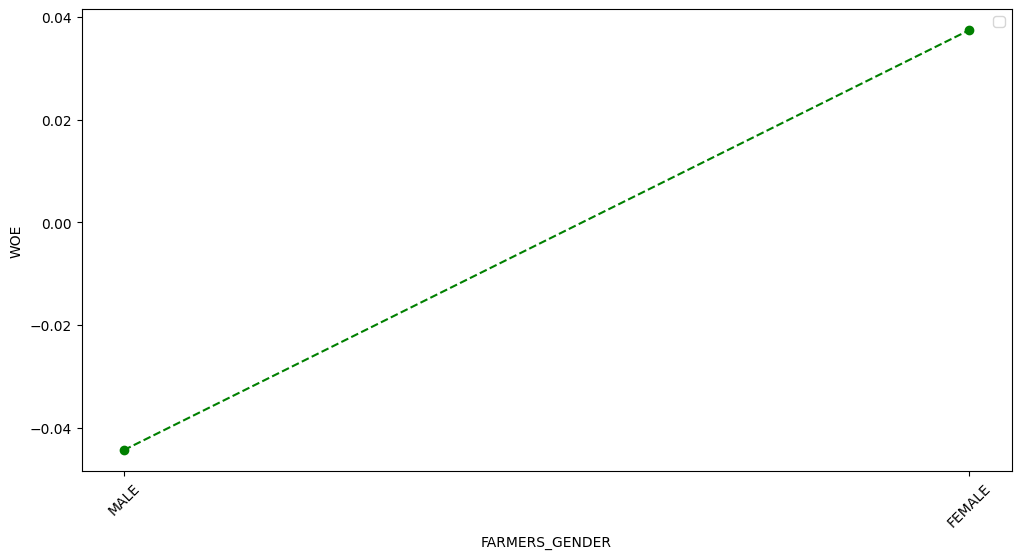



 SALES_CHANNEL


,SALES_CHANNEL,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,INFIELD,707,1568,0.450893,0.542178,0.361765,-0.404600,0.072995,0.26577
1,REFERRALS,276,626,0.440895,0.211656,0.147059,-0.364132,0.023522,0.26577
2,RENEWAL,321,1490,0.215436,0.246166,0.491176,0.690799,0.169253,0.26577


/tmp/ipython-input-2511047857.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


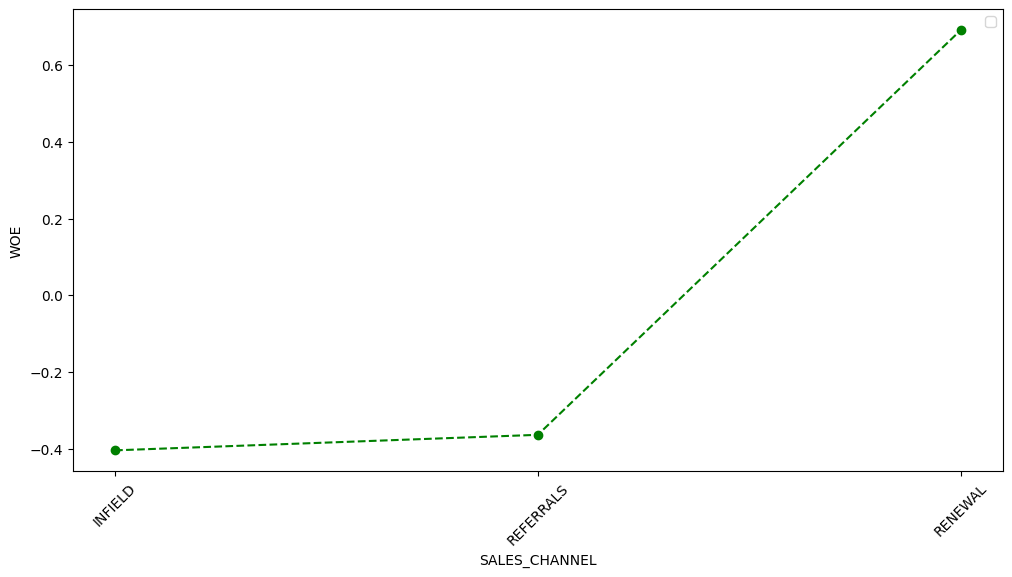



 CREDIT_SEGMENT


,CREDIT_SEGMENT,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
2,New_Tier 3 + New_Tier 4 + New_Tier 5 + New_Tier 6,445,745,0.597315,0.341258,0.126050,-0.995956,2.143369e-01,0.517396
1,New_Tier 2,338,775,0.436129,0.259202,0.183613,-0.344777,2.606133e-02,0.517396
5,Renewal_Tier 7 + Renewal_Tier 8,161,455,0.353846,0.123466,0.123529,0.000511,3.229563e-08,0.517396
0,New_Tier 0 + New_Tier 1,186,620,0.300000,0.142638,0.182353,0.245634,9.755324e-03,0.517396
4,Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier...,100,590,0.169492,0.076687,0.205882,0.987571,1.275895e-01,0.517396
3,Renewal_Tier 1 + Renewal_Tier 2 + Renewal_Tier 6,74,499,0.148297,0.056748,0.178571,1.146360,1.396530e-01,0.517396


/tmp/ipython-input-2511047857.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


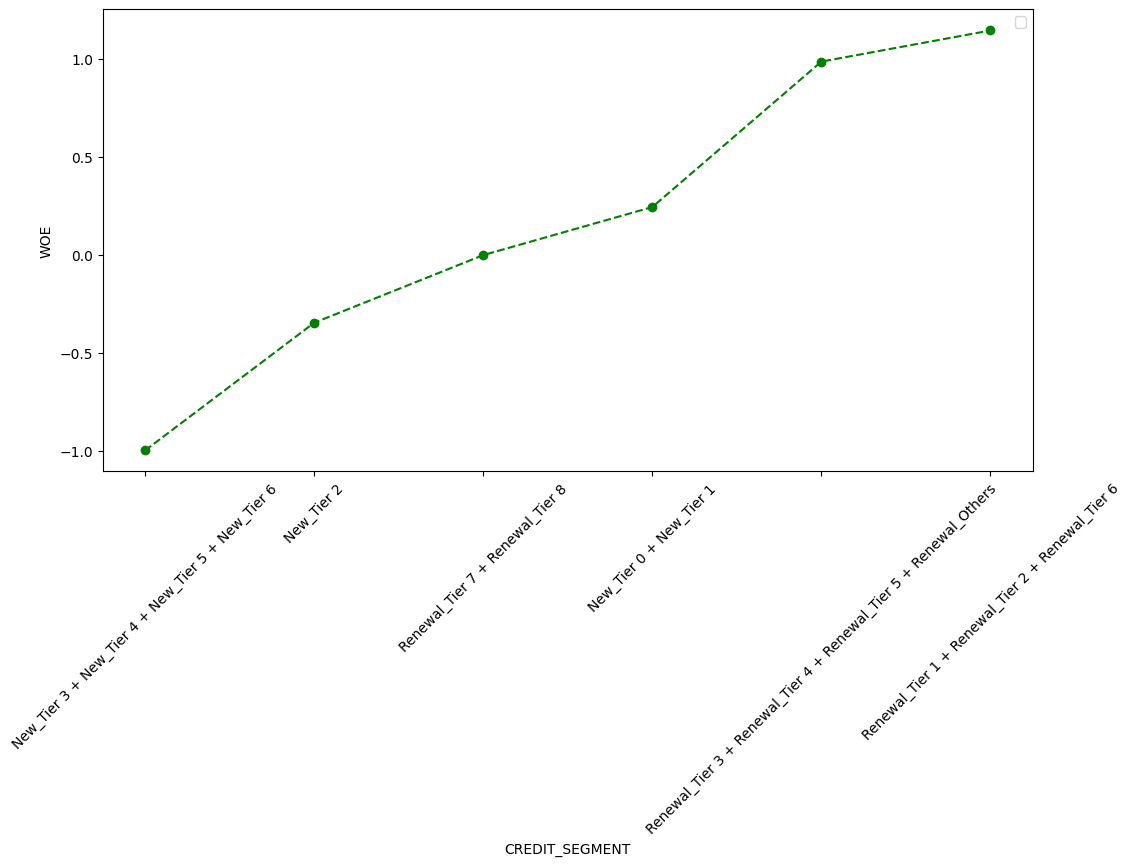



 REPEAT_CUSTOMER_FLAG


,REPEAT_CUSTOMER_FLAG,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,No,969,2140,0.452804,0.743098,0.492017,-0.412315,0.103525,0.2747
1,Yes,335,1544,0.216969,0.256902,0.507983,0.681754,0.171176,0.2747


/tmp/ipython-input-2511047857.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


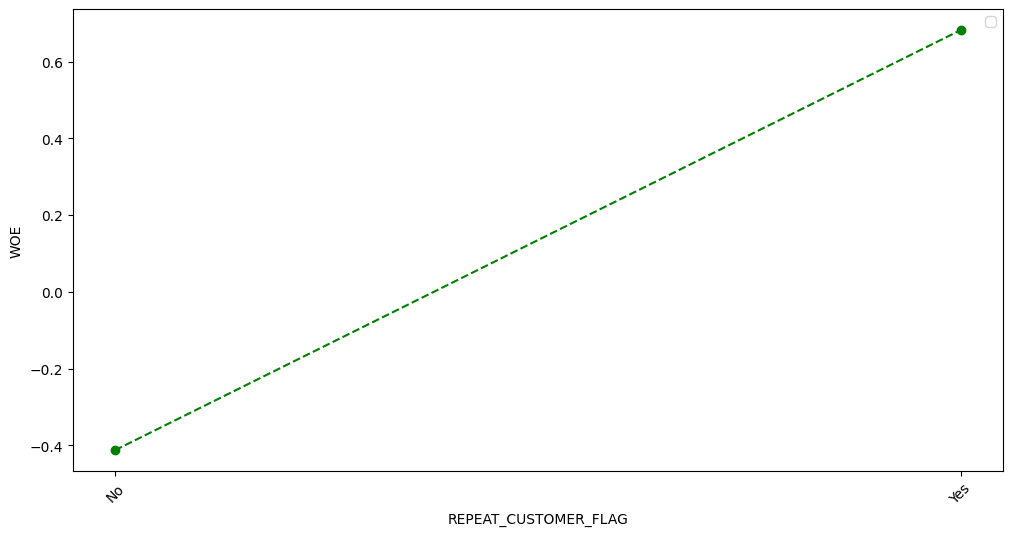

,Feature,Information_Value
3,CREDIT_SEGMENT,0.517396
4,REPEAT_CUSTOMER_FLAG,0.274700
2,SALES_CHANNEL,0.265770
0,COUNTY,0.080769
1,FARMERS_GENDER,0.001663


In [15]:
IV_table=pd.DataFrame(columns=['Feature','Information_Value'])
for i in cat_cols:
  print("\n\n",i)
  df_drate=df.groupby(i)['Default'].agg(['sum','count']).reset_index()
  df_drate['def_rate']=df_drate['sum']/df_drate['count']
  df_drate['%bad']=df_drate['sum']/df_drate['sum'].sum()
  df_drate['%good']=(df_drate['count']-df_drate['sum'])/(df_drate['count'].sum()-df_drate['sum'].sum())
  df_drate['WOE']=np.log((df_drate['%good']+0.00000000000000000001)/(df_drate['%bad']+0.00000000000000000001))
  df_drate=df_drate.sort_values(by='WOE',ascending=True)
  df_drate['IV_step']=((df_drate['%good']-df_drate['%bad'])*df_drate['WOE'])
  df_drate['IV']=df_drate['IV_step'].sum()
  display(df_drate.sort_values(by='WOE',ascending=True))
  plt.figure(figsize=(12, 6))
  plt.plot(df_drate[i],df_drate['WOE'],'go--')
  plt.xlabel(i)
  plt.ylabel('WOE')
  plt.legend()
  plt.xticks(rotation=45)
  plt.show()
  IV_table = pd.concat([IV_table,pd.DataFrame([{'Feature':i,'Information_Value':df_drate['IV_step'].sum()}])],ignore_index=True)
IV_table=IV_table.sort_values(by='Information_Value',ascending=False)
display(IV_table)


['DISBURSED_LIABILITY', 'O/s on default', 'DEPOSIT', 'INTEREST_RATE', 'DPD_SLOPE']
DISBURSED_LIABILITY


/tmp/ipython-input-947360064.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_drate=df_tmp.groupby('bin')['Default'].agg(['sum','count']).reset_index()


,bin,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,"(1246.07, 2147.6]",1,3,0.333333,0.000767,0.000840,0.091483,6.720807e-06,0.187251
1,"(2147.6, 3006.2]",11,17,0.647059,0.008436,0.002521,-1.207800,7.143622e-03,0.187251
2,"(3006.2, 3864.8]",7,17,0.411765,0.005368,0.004202,-0.244989,2.857595e-04,0.187251
3,"(3864.8, 4723.4]",16,56,0.285714,0.012270,0.016807,0.314627,1.427393e-03,0.187251
4,"(4723.4, 5582.0]",3,37,0.081081,0.002301,0.014286,1.826084,2.188580e-02,0.187251
5,"(5582.0, 6440.6]",17,71,0.239437,0.013037,0.022689,0.554107,5.348385e-03,0.187251
6,"(6440.6, 7299.2]",21,54,0.388889,0.016104,0.013866,-0.149679,3.350934e-04,0.187251
7,"(7299.2, 8157.8]",35,112,0.312500,0.026840,0.032353,0.186793,1.029689e-03,0.187251
8,"(8157.8, 9016.4]",59,175,0.337143,0.045245,0.048739,0.074389,2.599214e-04,0.187251
9,"(9016.4, 9875.0]",64,170,0.376471,0.049080,0.044538,-0.097108,4.410587e-04,0.187251


/tmp/ipython-input-947360064.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


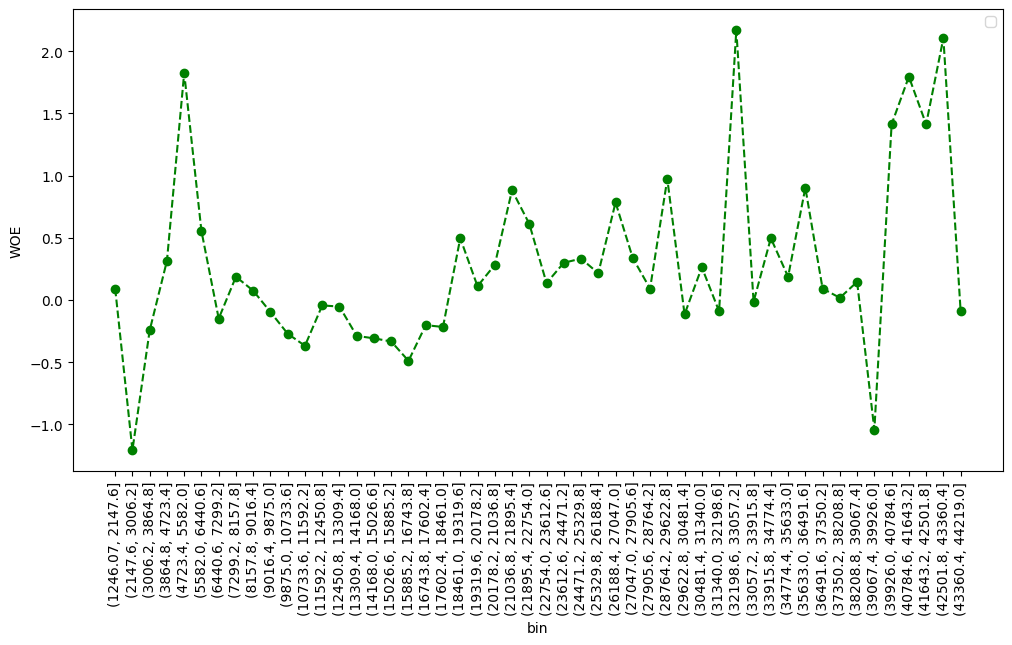

O/s on default


/tmp/ipython-input-947360064.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  IV_table_num = pd.concat([IV_table_num,pd.DataFrame([{'Feature':i,'Information_Value':df_drate['IV_step'].sum()}])],ignore_index=True)
/tmp/ipython-input-947360064.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_drate=df_tmp.groupby('bin')['Default'].agg(['sum','count']).reset_index()
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,bin,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,"(-14.766, 295.32]",1,2381,0.00042,0.000767,1.0,7.173192,7.167691,inf
1,"(295.32, 590.64]",5,5,1.00000,0.003834,0.0,-inf,inf,inf
2,"(590.64, 885.96]",13,13,1.00000,0.009969,0.0,-inf,inf,inf
3,"(885.96, 1181.28]",35,35,1.00000,0.026840,0.0,-inf,inf,inf
4,"(1181.28, 1476.6]",35,35,1.00000,0.026840,0.0,-inf,inf,inf
5,"(1476.6, 1771.92]",45,45,1.00000,0.034509,0.0,-inf,inf,inf
6,"(1771.92, 2067.24]",48,48,1.00000,0.036810,0.0,-inf,inf,inf
7,"(2067.24, 2362.56]",42,42,1.00000,0.032209,0.0,-inf,inf,inf
8,"(2362.56, 2657.88]",53,53,1.00000,0.040644,0.0,-inf,inf,inf
9,"(2657.88, 2953.2]",41,41,1.00000,0.031442,0.0,-inf,inf,inf


/tmp/ipython-input-947360064.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


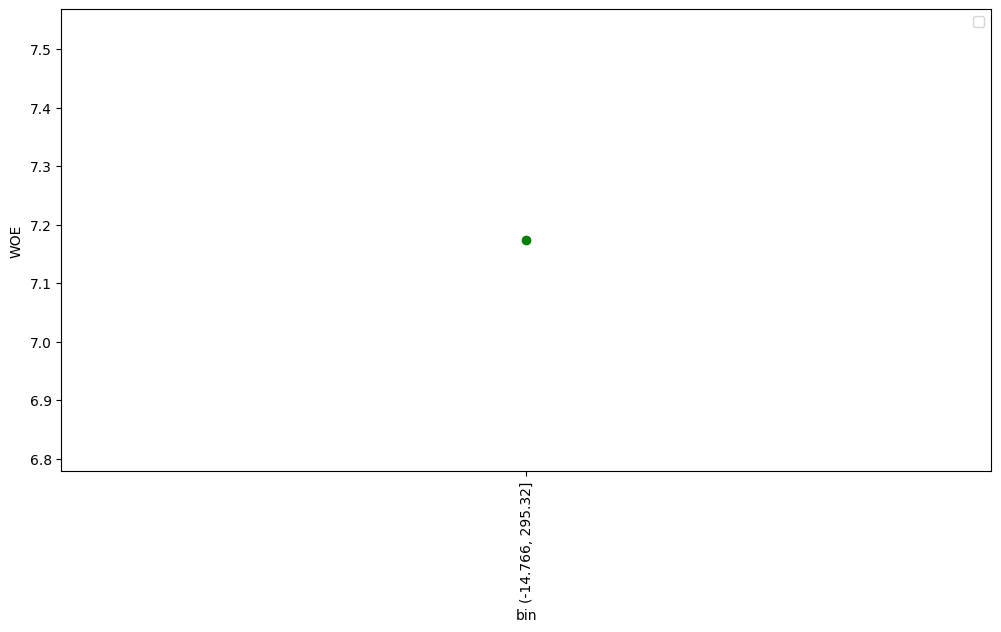

DEPOSIT


/tmp/ipython-input-947360064.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_drate=df_tmp.groupby('bin')['Default'].agg(['sum','count']).reset_index()


,bin,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,"(0.0499, 0.052]",225,1027,0.219085,0.172546,0.336975,0.669344,0.110059,0.212666
1,"(0.052, 0.054]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666
2,"(0.054, 0.056]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666
3,"(0.056, 0.058]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666
4,"(0.058, 0.06]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666
5,"(0.06, 0.062]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666
6,"(0.062, 0.064]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666
7,"(0.064, 0.066]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666
8,"(0.066, 0.068]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666
9,"(0.068, 0.07]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.212666


/tmp/ipython-input-947360064.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


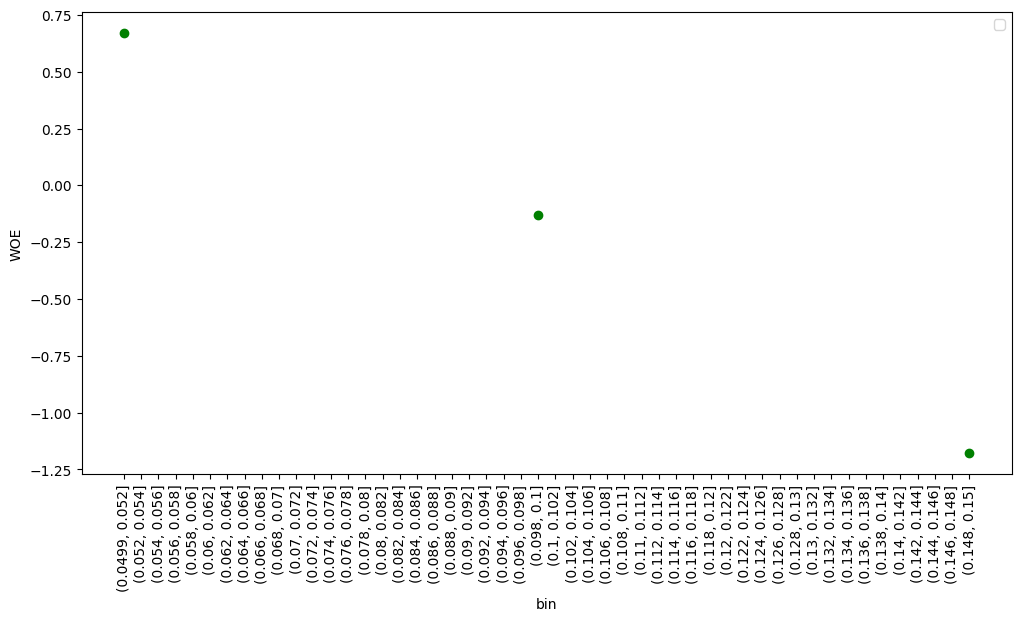

INTEREST_RATE


/tmp/ipython-input-947360064.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_drate=df_tmp.groupby('bin')['Default'].agg(['sum','count']).reset_index()


,bin,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,"(0.0688, 0.0693]",17,49,0.346939,0.013037,0.013445,0.030859,0.000013,0.362319
1,"(0.0693, 0.0699]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319
2,"(0.0699, 0.0704]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319
3,"(0.0704, 0.0709]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319
4,"(0.0709, 0.0715]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319
5,"(0.0715, 0.072]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319
6,"(0.072, 0.0725]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319
7,"(0.0725, 0.0731]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319
8,"(0.0731, 0.0736]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319
9,"(0.0736, 0.0741]",0,0,NaN,0.000000,0.000000,NaN,NaN,0.362319


/tmp/ipython-input-947360064.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


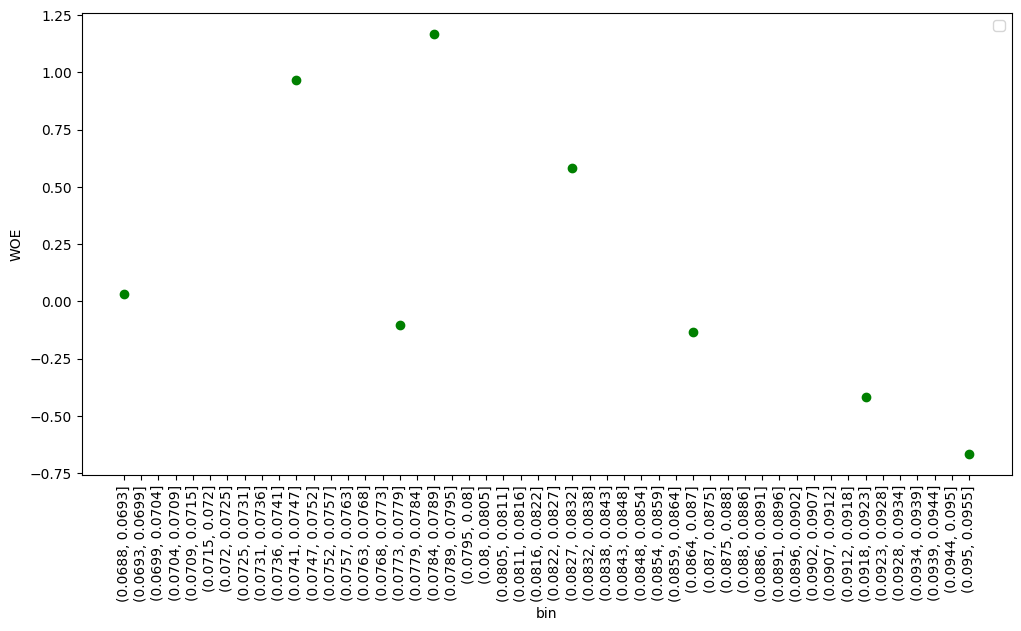

DPD_SLOPE


/tmp/ipython-input-947360064.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_drate=df_tmp.groupby('bin')['Default'].agg(['sum','count']).reset_index()
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,bin,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,"(-0.181, -0.176]",1,44,0.022727,0.000767,0.018067,3.159536,0.054661,inf
1,"(-0.176, -0.171]",0,63,0.000000,0.000000,0.026471,inf,inf,inf
2,"(-0.171, -0.166]",1,96,0.010417,0.000767,0.039916,3.952213,0.154726,inf
3,"(-0.166, -0.161]",0,124,0.000000,0.000000,0.052101,inf,inf,inf
4,"(-0.161, -0.156]",2,189,0.010582,0.001534,0.078571,3.936297,0.303243,inf
5,"(-0.156, -0.151]",2,149,0.013423,0.001534,0.061765,3.695621,0.222591,inf
6,"(-0.151, -0.147]",5,180,0.027778,0.003834,0.073529,2.953684,0.205857,inf
7,"(-0.147, -0.142]",4,202,0.019802,0.003067,0.083193,3.300309,0.264440,inf
8,"(-0.142, -0.137]",12,202,0.059406,0.009202,0.079832,2.160453,0.152592,inf
9,"(-0.137, -0.132]",8,193,0.041451,0.006135,0.077731,2.539250,0.181800,inf


/tmp/ipython-input-947360064.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


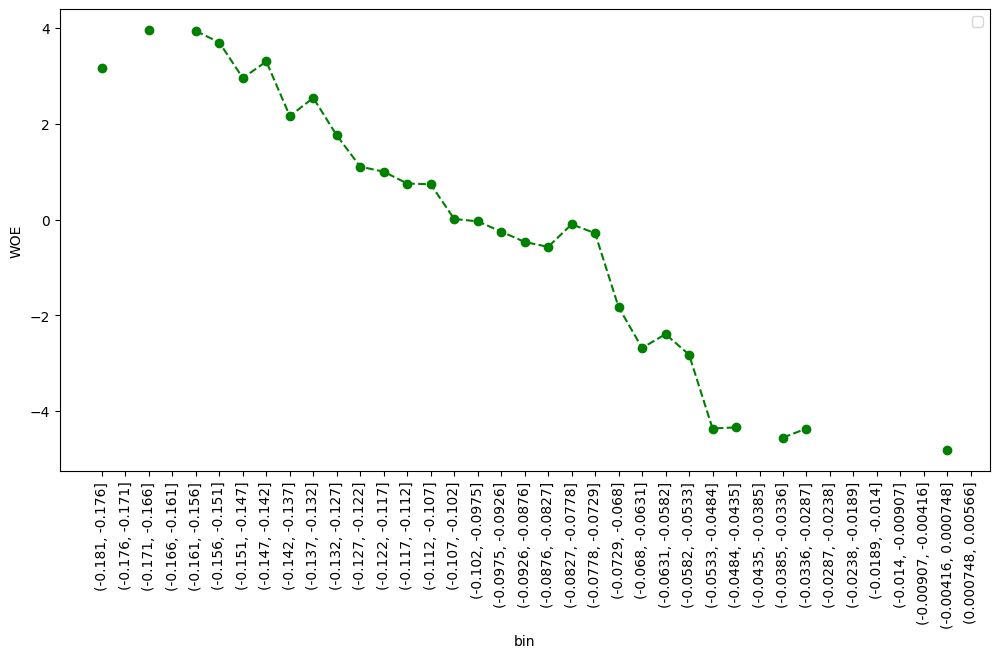

,Feature,Information_Value
1,O/s on default,inf
4,DPD_SLOPE,inf
3,INTEREST_RATE,0.362319
2,DEPOSIT,0.212666
0,DISBURSED_LIABILITY,0.187251


In [16]:
df1=df.drop("Default",axis=1)
IV_table_num=pd.DataFrame(columns=['Feature','Information_Value'])
num_cols = [col for col in df1.columns if col not in cat_cols]
print(num_cols)
for i in num_cols:
  print(i)
  df_tmp = df.loc[:,[i, 'Default']]
  df_tmp['bin'] = pd.cut(df_tmp[i],bins=50,duplicates='drop')
  df_drate=df_tmp.groupby('bin')['Default'].agg(['sum','count']).reset_index()
  df_drate['def_rate']=df_drate['sum']/df_drate['count']
  df_drate['%bad']=df_drate['sum']/df_drate['sum'].sum()
  df_drate['%good']=(df_drate['count']-df_drate['sum'])/(df_drate['count'].sum()-df_drate['sum'].sum())
  df_drate['WOE']=np.log((df_drate['%good'])/(df_drate['%bad']))
  df_drate['IV_step']=((df_drate['%good']-df_drate['%bad'])*df_drate['WOE'])
  df_drate['IV']=df_drate['IV_step'].sum()
  display(df_drate)
  plt.figure(figsize=(12, 6))
  plt.plot(df_drate['bin'].astype(str) ,df_drate['WOE'],'go--')
  plt.xlabel('bin')
  plt.ylabel('WOE')
  plt.legend()
  plt.xticks(rotation=90)
  plt.show()
  IV_table_num = pd.concat([IV_table_num,pd.DataFrame([{'Feature':i,'Information_Value':df_drate['IV_step'].sum()}])],ignore_index=True)
IV_table_num=IV_table_num.sort_values(by='Information_Value',ascending=False)
display(IV_table_num)

In [17]:
df['DISBURSED_LIABILITY']=np.where(
        (df['DISBURSED_LIABILITY']<10000),"<10000",
        np.where(
            (df['DISBURSED_LIABILITY']>=10000) & (df['DISBURSED_LIABILITY']<14000),"10000-14000",
            np.where(
                (df['DISBURSED_LIABILITY']>=14000) & (df['DISBURSED_LIABILITY']<19000),"14000-19000",
                np.where(
                    (df['DISBURSED_LIABILITY']>=19000) & (df['DISBURSED_LIABILITY']<25000),"19000-25000",
                    np.where(
                        (df['DISBURSED_LIABILITY']>=25000) & (df['DISBURSED_LIABILITY']<30000),"25000-30000",
                        np.where(
                            (df['DISBURSED_LIABILITY']>=30000) & (df['DISBURSED_LIABILITY']<50000),"30000-50000",
                            ">50000"
                            ))))))


df['DEPOSIT']=np.where(df['DEPOSIT']<0.06,"<0.06",
                       np.where((df['DEPOSIT']>=0.06)&(df['DEPOSIT']>=0.11),"0.06-0.11",
                                np.where((df['DEPOSIT']>=0.11)&(df['DEPOSIT']>=0.15),"0.11-0.15",
                                         np.where((df['DEPOSIT']>=0.15)&(df['DEPOSIT']>=0.21),"0.15-0.21",">0.21"))))


df['INTEREST_RATE']=np.where(df['INTEREST_RATE']<0.07,"<0.07",
                             np.where((df['INTEREST_RATE']>=0.07)&(df['INTEREST_RATE']<0.075),"0.07-0.075",
                                      np.where((df['INTEREST_RATE']>=0.075)&(df['INTEREST_RATE']<0.0785),"0.075-0.0785",
                                               np.where((df['INTEREST_RATE']>=0.0785)&(df['INTEREST_RATE']<0.0795),"0.0785-0.0795",
                                                        np.where((df['INTEREST_RATE']>=0.0795)&(df['INTEREST_RATE']<0.084),"0.0795-0.084",
                                                                 np.where((df['INTEREST_RATE']>=0.084)&(df['INTEREST_RATE']<0.087),"0.084-0.087",
                                                                          np.where((df['INTEREST_RATE']>=0.087)&(df['INTEREST_RATE']<0.093),"0.087-0.093",
                                                                                   np.where((df['INTEREST_RATE']>=0.093),">0.093","-"))))))))

df['DPD_SLOPE']=np.where(df['DPD_SLOPE']<=-0.151,"<-0.151",
                             np.where((df['DPD_SLOPE']>-0.151)&(df['DPD_SLOPE']<=-0.127),"-0.151 - -0.127",
                                      np.where((df['DPD_SLOPE']>-0.127)&(df['DPD_SLOPE']<=-0.107),"-0.127 - -0.107",
                                               np.where((df['DPD_SLOPE']>-0.107)&(df['DPD_SLOPE']<=-0.0827),"-0.107 - -0.0827",
                                                        np.where((df['DPD_SLOPE']>-0.0827)&(df['DPD_SLOPE']<=-0.0582),"-0.0827 - -0.0582",
                                                                 np.where((df['DPD_SLOPE']>-0.0582)&(df['DPD_SLOPE']<=-0.0287),"-0.0582 - -0.0287",
                                                                          np.where((df['DPD_SLOPE']>-0.0287)&(df['DPD_SLOPE']<=-0.014),"-0.0287 - -0.014",
                                                                                   np.where((df['DPD_SLOPE']>-0.014)&(df['DPD_SLOPE']<=-0.00416),"-0.014 - -0.00416",
                                                                                            np.where((df['DPD_SLOPE']>-0.00416)&(df['DPD_SLOPE']<=0.000748),"-0.00416 - 0.000748",
                                                                                                     np.where((df['DPD_SLOPE']>0.000748),">0.000748","-"))))))))))


Index(['DISBURSED_LIABILITY', 'COUNTY', 'FARMERS_GENDER', 'SALES_CHANNEL',
       'CREDIT_SEGMENT', 'DEPOSIT', 'INTEREST_RATE', 'REPEAT_CUSTOMER_FLAG',
       'DPD_SLOPE'],
      dtype='object')



 DISBURSED_LIABILITY


,DISBURSED_LIABILITY,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
1,14000-19000,365,864,0.422454,0.279908,0.209664,-0.288955,0.020297,0.069331
0,10000-14000,387,972,0.398148,0.296779,0.245798,-0.188477,0.009609,0.069331
5,<10000,248,744,0.333333,0.190184,0.208403,0.091483,0.001667,0.069331
4,30000-50000,84,300,0.280000,0.064417,0.090756,0.342798,0.009029,0.069331
2,19000-25000,154,561,0.274510,0.118098,0.171008,0.370197,0.019587,0.069331
3,25000-30000,66,243,0.271605,0.050613,0.074370,0.384831,0.009142,0.069331


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


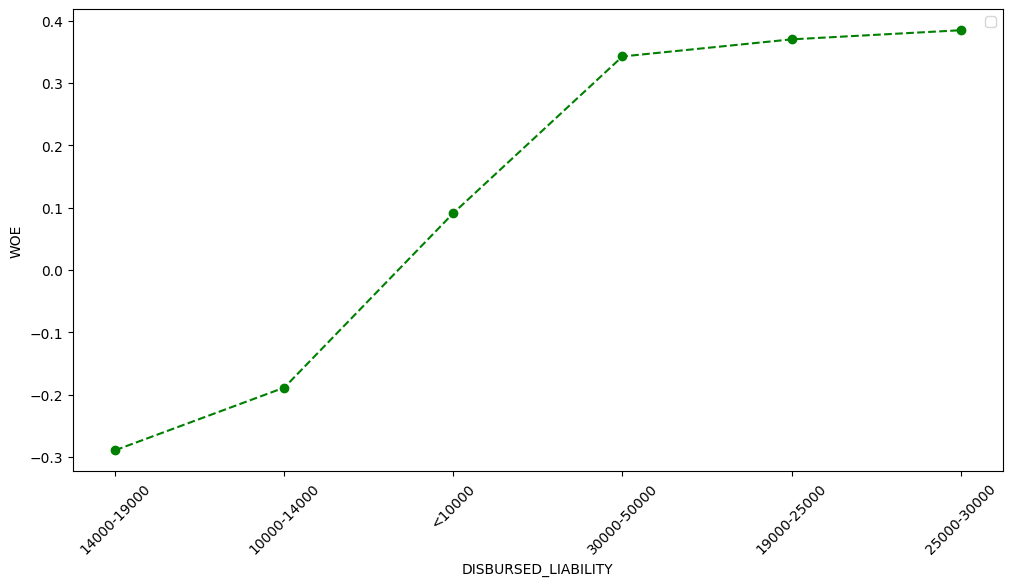



 COUNTY


/tmp/ipython-input-2114403405.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  IV_table_new = pd.concat([IV_table_new,pd.DataFrame([{'Feature':i,'Information_Value':round(df_drate['IV_step'].sum(),2)}])],ignore_index=True)


,COUNTY,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
3,Kisumu,44,86,0.511628,0.033742,0.017647,-0.648184,0.010433,0.080769
6,Siaya+Busia,178,394,0.451777,0.136503,0.090756,-0.408169,0.018672,0.080769
2,Kakamega+Nyamira,224,549,0.408015,0.171779,0.136555,-0.229485,0.008083,0.080769
5,Narok+West Pokot,77,199,0.386935,0.059049,0.051261,-0.141448,0.001102,0.080769
0,Bungoma+Vihiga+Nandi+Kericho+Kisii,447,1241,0.360193,0.342791,0.333613,-0.027139,0.000249,0.080769
1,Elgeyo-Marakwet+Nyandarua+Baringo,107,378,0.283069,0.082055,0.113866,0.327626,0.010422,0.080769
4,Nakuru+Uasin Gishu+Trans Nzoia,227,837,0.271207,0.174080,0.256303,0.386845,0.031807,0.080769


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


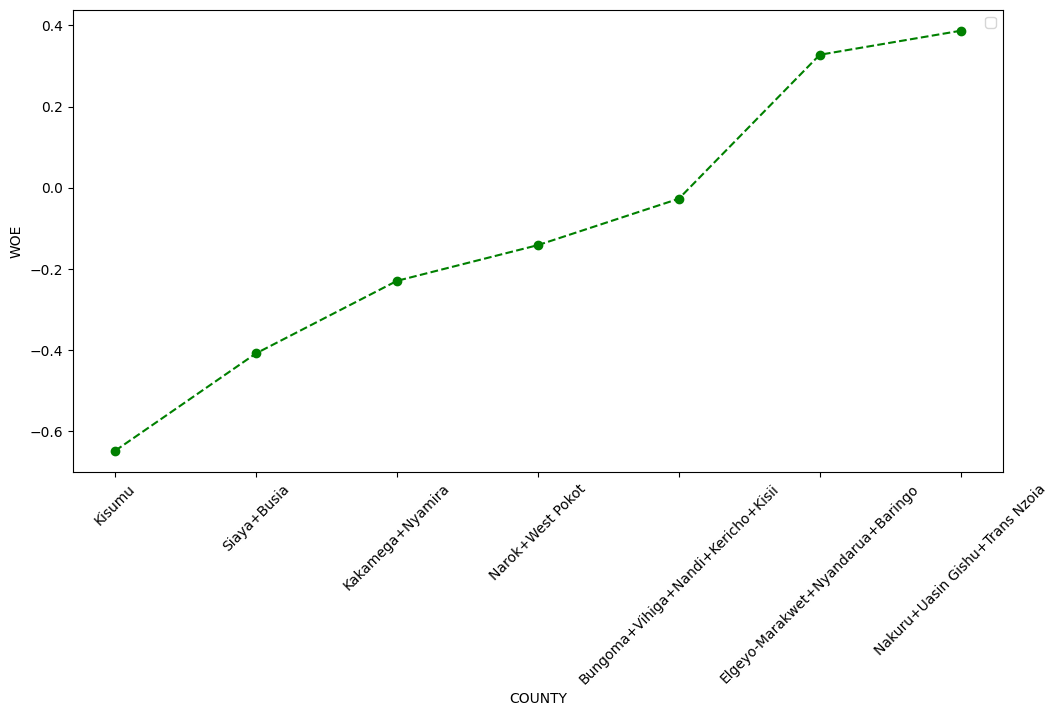



 FARMERS_GENDER


,FARMERS_GENDER,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
1,MALE,610,1675,0.364179,0.467791,0.447479,-0.044393,0.000902,0.001663
0,FEMALE,694,2009,0.345445,0.532209,0.552521,0.037456,0.000761,0.001663


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


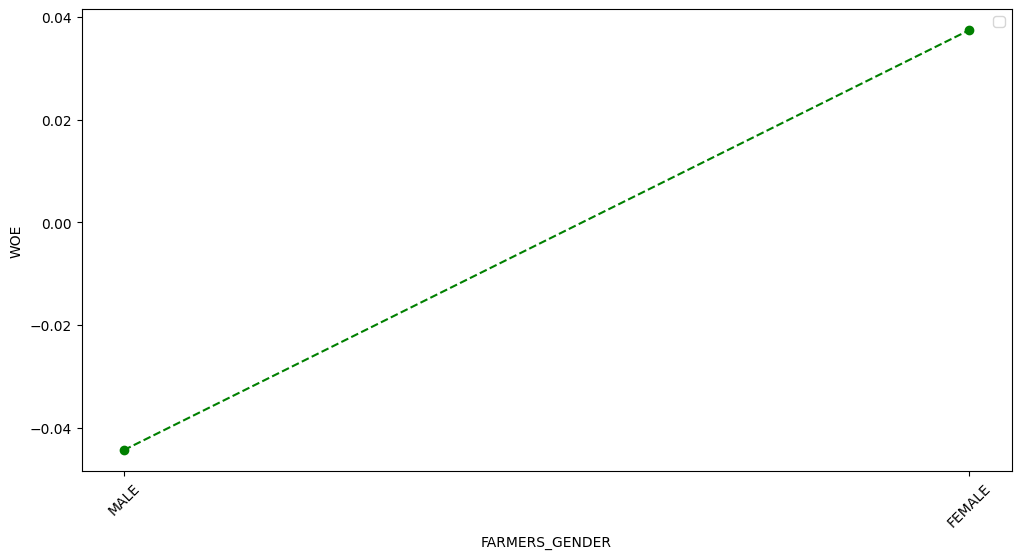



 SALES_CHANNEL


,SALES_CHANNEL,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,INFIELD,707,1568,0.450893,0.542178,0.361765,-0.404600,0.072995,0.26577
1,REFERRALS,276,626,0.440895,0.211656,0.147059,-0.364132,0.023522,0.26577
2,RENEWAL,321,1490,0.215436,0.246166,0.491176,0.690799,0.169253,0.26577


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


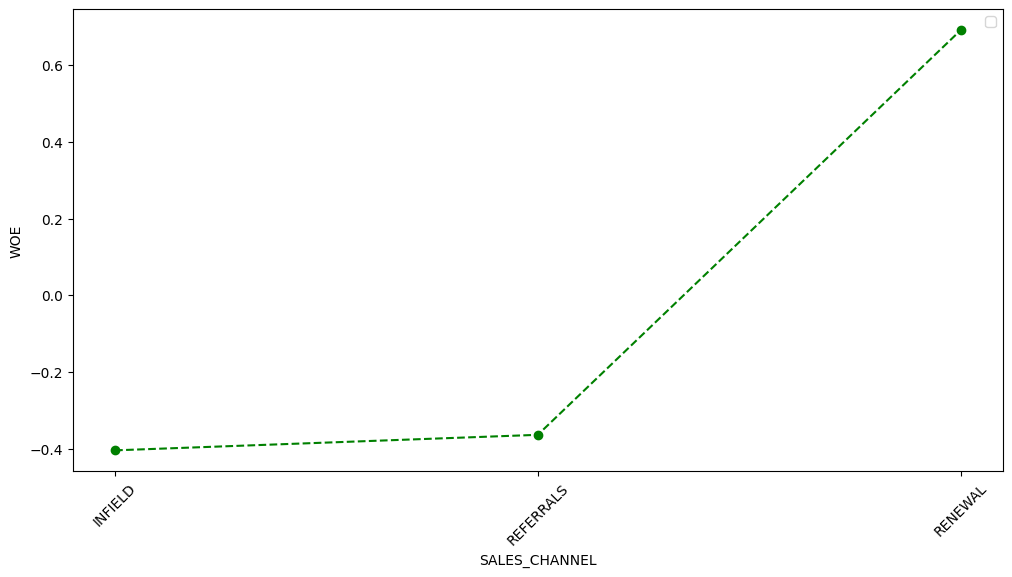



 CREDIT_SEGMENT


,CREDIT_SEGMENT,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
2,New_Tier 3 + New_Tier 4 + New_Tier 5 + New_Tier 6,445,745,0.597315,0.341258,0.126050,-0.995956,2.143369e-01,0.517396
1,New_Tier 2,338,775,0.436129,0.259202,0.183613,-0.344777,2.606133e-02,0.517396
5,Renewal_Tier 7 + Renewal_Tier 8,161,455,0.353846,0.123466,0.123529,0.000511,3.229563e-08,0.517396
0,New_Tier 0 + New_Tier 1,186,620,0.300000,0.142638,0.182353,0.245634,9.755324e-03,0.517396
4,Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier...,100,590,0.169492,0.076687,0.205882,0.987571,1.275895e-01,0.517396
3,Renewal_Tier 1 + Renewal_Tier 2 + Renewal_Tier 6,74,499,0.148297,0.056748,0.178571,1.146360,1.396530e-01,0.517396


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


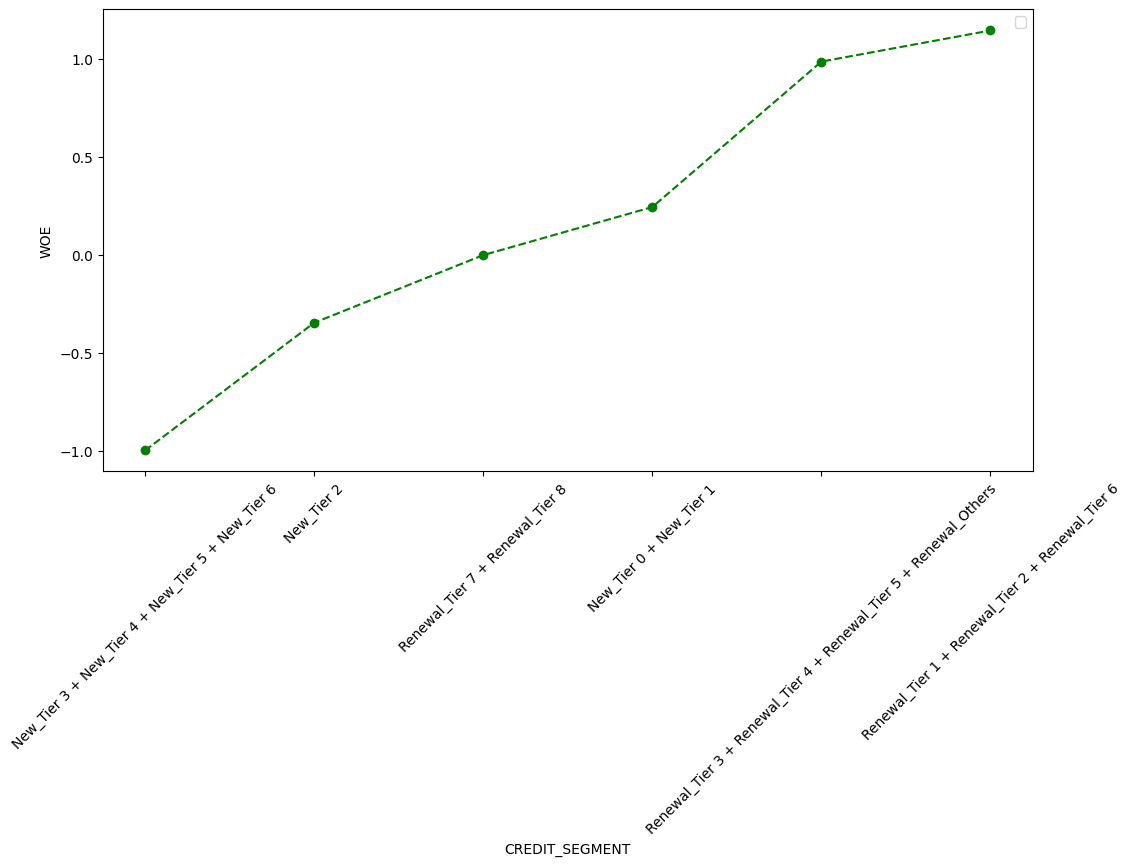



 DEPOSIT


,DEPOSIT,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,0.06-0.11,146,228,0.640351,0.111963,0.034454,-1.178551,0.091349,0.212666
2,>0.21,933,2429,0.384109,0.715491,0.628571,-0.129519,0.011258,0.212666
1,<0.06,225,1027,0.219085,0.172546,0.336975,0.669344,0.110059,0.212666


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


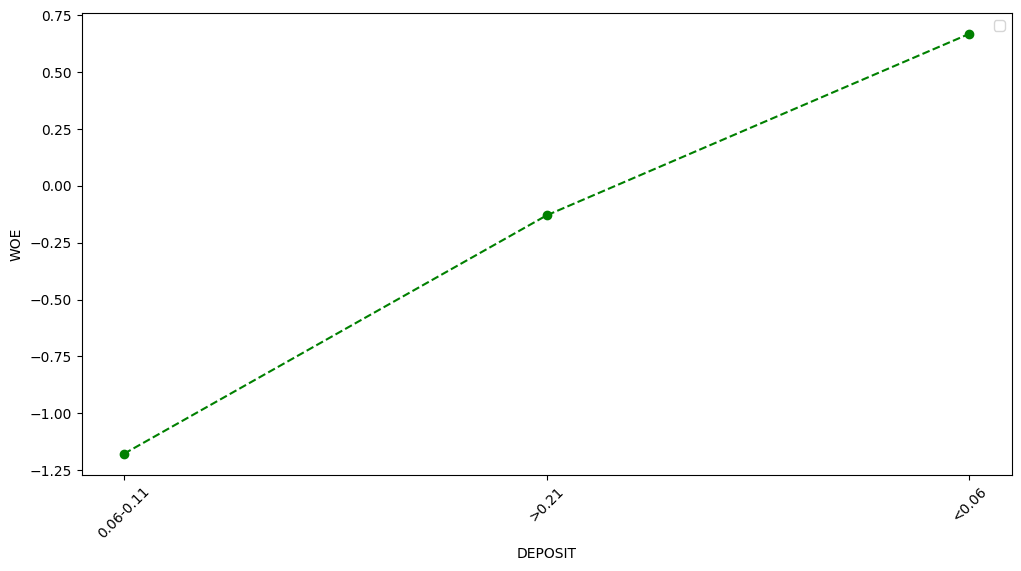



 INTEREST_RATE


,INTEREST_RATE,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
7,>0.093,591,1145,0.516157,0.453221,0.232773,-0.666315,0.146888,0.362319
5,0.087-0.093,25,55,0.454545,0.019172,0.012605,-0.419342,0.002754,0.362319
4,0.084-0.087,173,449,0.385301,0.132669,0.115966,-0.134555,0.002247,0.362319
1,0.075-0.0785,188,497,0.378270,0.144172,0.129832,-0.104765,0.001502,0.362319
6,<0.07,17,49,0.346939,0.013037,0.013445,0.030859,0.000013,0.362319
3,0.0795-0.084,228,973,0.234327,0.174847,0.313025,0.582375,0.080472,0.362319
0,0.07-0.075,44,255,0.172549,0.033742,0.088655,0.966004,0.053046,0.362319
2,0.0785-0.0795,38,261,0.145594,0.029141,0.093697,1.167922,0.075397,0.362319


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


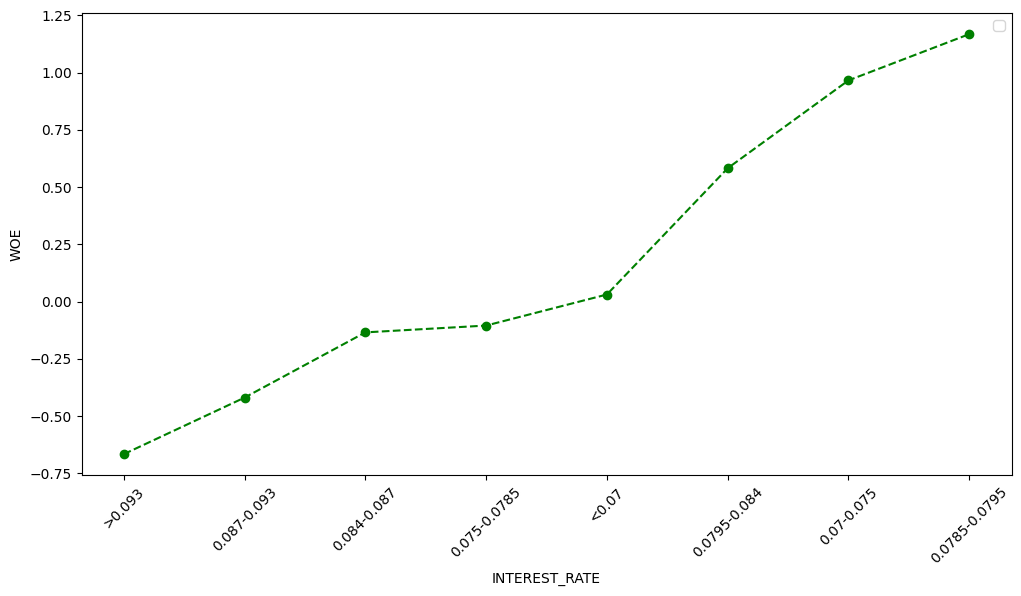



 REPEAT_CUSTOMER_FLAG


,REPEAT_CUSTOMER_FLAG,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
0,No,969,2140,0.452804,0.743098,0.492017,-0.412315,0.103525,0.2747
1,Yes,335,1544,0.216969,0.256902,0.507983,0.681754,0.171176,0.2747


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


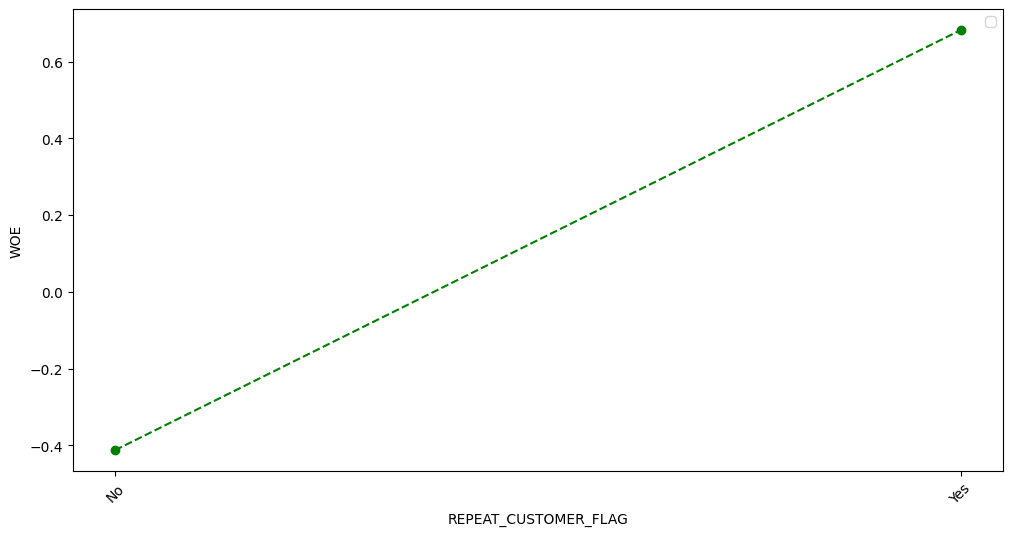



 DPD_SLOPE


,DPD_SLOPE,sum,count,def_rate,%bad,%good,WOE,IV_step,IV
2,-0.0287 - -0.014,171,171,1.000000,0.131135,0.000000,-44.020174,5.772584,15.737237
1,-0.014 - -0.00416,132,132,1.000000,0.101227,0.000000,-43.761312,4.429826,15.737237
9,>0.000748,57,57,1.000000,0.043712,0.000000,-42.921561,1.876173,15.737237
0,-0.00416 - 0.000748,203,206,0.985437,0.155675,0.001261,-4.816258,0.743699,15.737237
3,-0.0582 - -0.0287,263,272,0.966912,0.201687,0.003782,-3.976593,0.786990,15.737237
4,-0.0827 - -0.0582,170,282,0.602837,0.130368,0.047059,-1.018964,0.084889,15.737237
5,-0.107 - -0.0827,154,374,0.411765,0.118098,0.092437,-0.244989,0.006287,15.737237
6,-0.127 - -0.107,103,566,0.181979,0.078988,0.194538,0.901334,0.104149,15.737237
7,-0.151 - -0.127,44,943,0.046660,0.033742,0.377731,2.415429,0.830881,15.737237
8,<-0.151,7,681,0.010279,0.005368,0.283193,3.965656,1.101759,15.737237


/tmp/ipython-input-2114403405.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


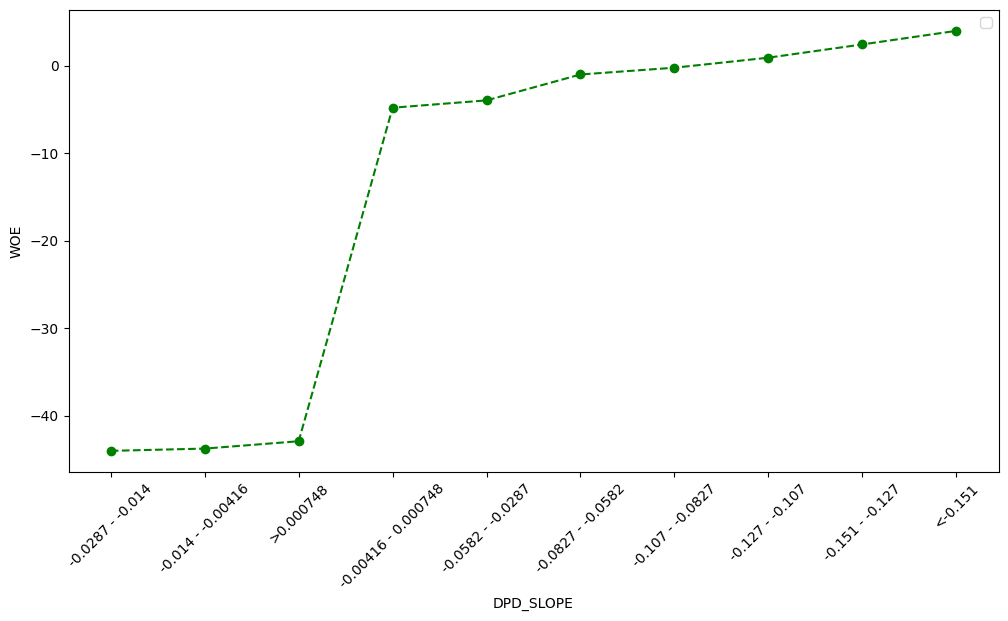

,Feature,Information_Value
0,DPD_SLOPE,15.74
1,CREDIT_SEGMENT,0.52
2,INTEREST_RATE,0.36
3,REPEAT_CUSTOMER_FLAG,0.27
4,SALES_CHANNEL,0.27
5,DEPOSIT,0.21
6,COUNTY,0.08
7,DISBURSED_LIABILITY,0.07
8,FARMERS_GENDER,0.00


In [18]:
new_cat_cols = df.select_dtypes(include='object').columns
display(new_cat_cols)
IV_table_new=pd.DataFrame(columns=['Feature','Information_Value'])
for i in new_cat_cols:
  print("\n\n",i)
  df_drate=df.groupby(i)['Default'].agg(['sum','count']).reset_index()
  df_drate['def_rate']=df_drate['sum']/df_drate['count']
  df_drate['%bad']=df_drate['sum']/df_drate['sum'].sum()
  df_drate['%good']=(df_drate['count']-df_drate['sum'])/(df_drate['count'].sum()-df_drate['sum'].sum())
  df_drate['WOE']=np.log((df_drate['%good']+0.00000000000000000001)/(df_drate['%bad']+0.00000000000000000001))
  df_drate=df_drate.sort_values(by='WOE',ascending=True)
  df_drate['IV_step']=((df_drate['%good']-df_drate['%bad'])*df_drate['WOE'])
  df_drate['IV']=df_drate['IV_step'].sum()
  display(df_drate.sort_values(by='WOE',ascending=True))
  plt.figure(figsize=(12, 6))
  plt.plot(df_drate[i],df_drate['WOE'],'go--')
  plt.xlabel(i)
  plt.ylabel('WOE')
  plt.legend()
  plt.xticks(rotation=45)
  plt.show()
  IV_table_new = pd.concat([IV_table_new,pd.DataFrame([{'Feature':i,'Information_Value':round(df_drate['IV_step'].sum(),2)}])],ignore_index=True)
IV_table_new=IV_table_new.sort_values(by='Information_Value',ascending=False,ignore_index=True)
display(IV_table_new)


In [19]:
new_features=IV_table_new.Feature[IV_table_new['Information_Value']>0.02]
display(new_features)

,Feature
0,DPD_SLOPE
1,CREDIT_SEGMENT
2,INTEREST_RATE
3,REPEAT_CUSTOMER_FLAG
4,SALES_CHANNEL
5,DEPOSIT
6,COUNTY
7,DISBURSED_LIABILITY


In [20]:
new_var = np.isin(df.columns.values, new_features.values)
target=df['Default']
df=pd.concat([df.loc[:, new_var],target],axis=1)

In [21]:
df_woe=df.copy()
for i in df.drop('Default',axis=1).columns:
  df_drate=df_woe.groupby(i)['Default'].agg(['sum','count']).reset_index()
  df_drate['def_rate']=df_drate['sum']/df_drate['count']
  df_drate['%bad']=df_drate['sum']/df_drate['sum'].sum()
  df_drate['%good']=(df_drate['count']-df_drate['sum'])/(df_drate['count'].sum()-df_drate['sum'].sum())
  df_drate['WOE']=np.log((df_drate['%good']+0.00000000000000000001)/(df_drate['%bad']+0.00000000000000000001))
  dict_woe = dict(zip(df_drate[i],df_drate['WOE']))
  df_woe[i]=df_woe[i].map(dict_woe)
df_woe

,DISBURSED_LIABILITY,COUNTY,SALES_CHANNEL,CREDIT_SEGMENT,DEPOSIT,INTEREST_RATE,REPEAT_CUSTOMER_FLAG,DPD_SLOPE,Default
LOAN_APPLICATION_ID,,,,,,,,,
1530738,-0.288955,-0.027139,-0.404600,0.245634,-0.129519,-0.104765,-0.412315,2.415429,0
1530769,-0.188477,-0.229485,0.690799,0.987571,0.669344,0.582375,0.681754,2.415429,0
1530797,0.384831,-0.229485,-0.404600,-0.344777,-0.129519,-0.134555,-0.412315,-42.921561,1
1530811,0.091483,-0.027139,0.690799,0.987571,0.669344,0.582375,0.681754,3.965656,0
1530938,0.370197,-0.229485,0.690799,0.987571,-0.129519,0.582375,0.681754,-44.020174,1
...,...,...,...,...,...,...,...,...,...
2088812,-0.188477,0.386845,-0.364132,-0.995956,0.669344,-0.666315,-0.412315,3.965656,0
2088904,-0.288955,-0.229485,-0.404600,-0.344777,-0.129519,-0.666315,-0.412315,2.415429,1
2089207,-0.188477,-0.229485,-0.404600,-0.344777,0.669344,-0.134555,-0.412315,3.965656,0


In [22]:
# Quick class-balance check
# imbalance if bad ratio < 20%
bad = df_woe["Default"].sum()
good = len(df_woe) - bad
ratio = bad / len(df_woe)

print(f"Total records   : {len(df_woe):,}")
print(f"Good (0) loans  : {good:,}  ({good/len(df_woe):.1%})")
print(f"Bad  (1) loans  : {bad:,}  ({ratio:.1%})")

Total records   : 3,684
Good (0) loans  : 2,380  (64.6%)
Bad  (1) loans  : 1,304  (35.4%)


In [23]:
df.isnull().sum()

,0
DISBURSED_LIABILITY,0
COUNTY,0
SALES_CHANNEL,0
CREDIT_SEGMENT,0
DEPOSIT,0
INTEREST_RATE,0
REPEAT_CUSTOMER_FLAG,0
DPD_SLOPE,0
Default,0


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

X = df_woe.drop(columns="Default")
y = df_woe["Default"]

X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

logit = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)

proba = logit.predict_proba(X_val)[:,1]
auc   = roc_auc_score(y_val, proba)
ks    = max(roc_curve(y_val, proba)[1] - roc_curve(y_val, proba)[0])

print(f"AUC={auc:.3f}  KS={ks:.3f}")


AUC=0.957  KS=0.766


AUC = 0.957 ≈ 95.7 % chance of correct ordering → excellent separation. Very few overlaps between good and bad score distributions.

KS = 0.766 = 76.6 % difference at the model’s best cut-off → the model captures ~77 % of bads before it starts accepting a big chunk of goods. Anything > 0.40 in retail credit is regarded as strong.

In [25]:
variables= X.columns.values.reshape(8,1)
coeficients=logit.coef_[0].round(2).reshape(8,1)
coe=pd.DataFrame(list(zip(X.columns.values, logit.coef_[0].round(2))), columns=['Variable','Coefficient'])
coe.loc[8,:]=['Intercept',logit.intercept_[0].round(2)]
coe

,Variable,Coefficient
0,DISBURSED_LIABILITY,-2.26
1,COUNTY,-0.21
2,SALES_CHANNEL,0.38
3,CREDIT_SEGMENT,-1.01
4,DEPOSIT,0.31
5,INTEREST_RATE,0.18
6,REPEAT_CUSTOMER_FLAG,-0.12
7,DPD_SLOPE,-1.01
8,Intercept,-0.69


In [26]:
# after fitting `logit_model`
df["Logit"] = logit.decision_function(df_woe.drop(columns="Default"))
logit_min = df["Logit"].min()
logit_max = df["Logit"].max()
df["Score"] = (850 - (df["Logit"] - logit_min) / (logit_max - logit_min) * (850 - 300)).round(0)


In [27]:
df.head()

,DISBURSED_LIABILITY,COUNTY,SALES_CHANNEL,CREDIT_SEGMENT,DEPOSIT,INTEREST_RATE,REPEAT_CUSTOMER_FLAG,DPD_SLOPE,Default,Logit,Score
LOAN_APPLICATION_ID,,,,,,,,,,,
1530738,14000-19000,Bungoma+Vihiga+Nandi+Kericho+Kisii,INFIELD,New_Tier 0 + New_Tier 1,>0.21,0.075-0.0785,No,-0.151 - -0.127,0,-2.892883,809.0
1530769,10000-14000,Kakamega+Nyamira,RENEWAL,Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier...,<0.06,0.0795-0.084,Yes,-0.151 - -0.127,0,-3.169880,811.0
1530797,25000-30000,Kakamega+Nyamira,INFIELD,New_Tier 2,>0.21,0.084-0.087,No,>0.000748,1,42.207863,335.0
1530811,<10000,Bungoma+Vihiga+Nandi+Kericho+Kisii,RENEWAL,Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier...,<0.06,0.0795-0.084,Yes,<-0.151,0,-5.419182,835.0
1530938,19000-25000,Kakamega+Nyamira,RENEWAL,Renewal_Tier 3 + Renewal_Tier 4 + Renewal_Tier...,>0.21,0.0795-0.084,Yes,-0.0287 - -0.014,1,42.428036,333.0


In [28]:
df.to_csv("/content/Apollo_Files/credit_score.csv")